# LightDP-FL / CIFAR-10 — four-method comparison with caching

**Colab: choose a GPU runtime → Run all.** All 50,000 training images and all 10,000 test images are used. The GPU pilot assigns a training plan within an approximately **110-minute target**, with checkpoints, measured timings and actual peak GPU allocations. Faster GPUs can finish earlier; there is no artificial delay. Download/initialization time and fluctuating Colab hardware prevent a strict wall-clock guarantee.

### What changed from v1

- **50,000 instead of 30,000 training images**, initially 50 clients × 1,000 images.
- Standard pretrained image resolution **224×224 instead of 96×96**, two cached training views (original and horizontal flip).
- A **trainable convolutional image branch plus classifier** now learns from raw pixels each round, alongside fixed public ResNet-18 features. This is a hybrid transfer-learning model, **not end-to-end ResNet-18 training**. The CNN branch and classifier are trained jointly from initialization; the public ResNet stays frozen. This preserves the useful pretrained representation without pretending that the whole ResNet is privately retrained.
- Up to **50 full-data rounds** for each main method, selected using a timed pilot; a separate equally budgeted parameter study starts every run from the same initialization.
- Same-model gradient reconstruction, training-time/peak-memory charts, explicit masking benchmarks, a small real Paillier encryption microbenchmark, and straggler/collusion graphs.

This is a concept replication of Hong, Lin & Duan, [Lightweight Federated Learning with Differential Privacy and Straggler Resilience](https://arxiv.org/abs/2412.06120). We do not promise a particular accuracy, an unreadable reconstruction, or lower runtime than every baseline. The old executed notebook reported LightDP accuracy around 78–79%; the new experiment must be measured independently.

### This update adds (and keeps the existing analyses)

**No DP, Vanilla local noise adding, SMPC+DP, and LightDP**. Three paper-style panels compare the three private methods at ε=3,6,9. No DP appears separately as a reference. Main runs are capped at **50 rounds**; the timing pilot can select fewer to fit the target because there are now ten main runs (nine private + one no-DP). Existing ten parameter sweeps remain, capped at ten rounds each.

Unchanged feature extraction, completed training, partial checkpoints and reconstruction results are reused from a dependency-keyed cache. Graph edits do not invalidate models. Persistent Google Drive caching is enabled below; Colab asks you to authorize mounting your own Drive. Set `USE_GOOGLE_DRIVE=False` for session-only caching. Existing v2 runs cannot be safely reused because this update changes the training plan and privacy calibration.

**An exact no-DP pixel reconstruction demonstration is added first.** It is a clearly labelled linear probe; the later reconstruction against the actual hybrid model remains. Exact recovery in a probe does not establish exact recovery of every image from the hybrid model.


In [1]:
import sys, subprocess, importlib.util
for package,module in [('scikit-image','skimage'),('pandas','pandas'),('scipy','scipy'),('psutil','psutil'),('phe','phe')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable,'-m','pip','install','-q',package])
import os,time,math,json,random,copy,gc,zipfile,platform,hashlib,inspect
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from skimage.metrics import structural_similarity
import psutil
import torch
from torch import nn
import torch.nn.functional as F
from torch.func import functional_call,grad,vmap
from torchvision import datasets,models,transforms
import torchvision
from IPython.display import display
START=time.monotonic()
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE=='cuda', 'Select Runtime > Change runtime type > GPU and rerun.'
OUT=Path('/content/lightdp_paper_comparison_results'); OUT.mkdir(parents=True,exist_ok=True)
CFG=dict(seed=2026,train_size=50000,n_clients=50,max_colluders=10,max_stragglers=10,
         epsilon=6.,delta=1e-5,clip=1.,lr=1.,momentum=.9,
         image_size=224,feature_batch=128,microbatch=32,
         requested_main_rounds=50,requested_sweep_rounds=10,
         target_minutes=110,diagnostic_reserve_minutes=15,
         attack_steps=700,attack_restarts=2,attack_ids=[0,1],
         feature_views=2)
SEED=CFG['seed']
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
torch.set_num_threads(2); torch.backends.cudnn.benchmark=True
def sync(): torch.cuda.synchronize()
def remaining_minutes(): return CFG['target_minutes']-(time.monotonic()-START)/60
print('GPU:',torch.cuda.get_device_name(), '| PyTorch:',torch.__version__)
display(pd.Series(CFG,name='Requested configuration'))
(OUT/'requested_config.json').write_text(json.dumps(CFG,indent=2))


USE_GOOGLE_DRIVE=True
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    CACHE=Path('/content/drive/MyDrive/LightDP_FL_cache_v3')
else:
    CACHE=Path('/content/lightdp_cache_v3')
CACHE.mkdir(parents=True,exist_ok=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,default=str).encode()).hexdigest()[:24]
def tensor_digest(t):
    return hashlib.sha256(t.detach().cpu().contiguous().numpy().tobytes()).hexdigest()
def cache_path(kind,key):
    folder=CACHE/kind;folder.mkdir(exist_ok=True)
    return folder/(key+'.pt')
def save_cache(path,data):
    temp=path.with_suffix('.tmp')
    torch.save(data,temp);os.replace(temp,path)
def read_cache(path):
    return torch.load(path,map_location='cpu',weights_only=False)
print('Cache directory:',CACHE)


def cache_source(obj):
    """Source when available; stable executable fingerprint for notebook objects."""
    try:
        return inspect.getsource(obj)
    except (OSError, TypeError):
        pass
    import types
    def encode(value):
        if inspect.isclass(value):
            return dict(class_reference=value.__module__+'.'+value.__qualname__)
        if isinstance(value, types.CodeType):
            return dict(bytecode=value.co_code.hex(),
                        constants=[encode(v) for v in value.co_consts],
                        names=value.co_names,variables=value.co_varnames,
                        free=value.co_freevars,cell=value.co_cellvars,
                        args=value.co_argcount,posonly=value.co_posonlyargcount,
                        kwonly=value.co_kwonlyargcount,flags=value.co_flags,
                        exceptions=getattr(value,'co_exceptiontable',b'').hex())
        if isinstance(value, types.FunctionType):
            return dict(code=encode(value.__code__),defaults=encode(value.__defaults__),
                        kwdefaults=encode(value.__kwdefaults__),
                        closure=[encode(c.cell_contents) for c in (value.__closure__ or ())])
        if isinstance(value,(staticmethod,classmethod)):
            return {type(value).__name__:encode(value.__func__)}
        if isinstance(value,property):
            return dict(property=[encode(value.fget),encode(value.fset),encode(value.fdel)])
        if value is None or isinstance(value,(bool,int,float,str)):
            return value
        if isinstance(value,bytes): return dict(bytes=value.hex())
        if isinstance(value,complex): return dict(complex=[value.real,value.imag])
        if value is Ellipsis: return dict(ellipsis=True)
        if isinstance(value,(tuple,list)): return [encode(v) for v in value]
        if isinstance(value,dict):return {str(k):encode(v) for k,v in sorted(value.items(),key=lambda kv:str(kv[0]))}
        if isinstance(value,(set,frozenset)):
            return dict(set=sorted([encode(v) for v in value],key=lambda v:json.dumps(v,sort_keys=True)))
        raise TypeError(f'Cannot safely fingerprint {type(value).__name__}; define this dependency in an importable Python file.')
    if inspect.isclass(obj):
        definition=dict(name=obj.__qualname__,bases=[b.__module__+'.'+b.__qualname__ for b in obj.__bases__],
                        members={name:encode(value) for name,value in sorted(vars(obj).items())
                                 if name not in {'__dict__','__weakref__','__module__','__doc__',
                                                 '__firstlineno__','__static_attributes__'}})
    else:
        definition=encode(obj)
    return 'notebook-executable-v1:'+json.dumps(definition,sort_keys=True,separators=(',',':'))


GPU: Tesla T4 | PyTorch: 2.11.0+cu128


,Requested configuration
seed,2026
train_size,50000
n_clients,50
max_colluders,10
max_stragglers,10
epsilon,6.0
delta,0.00001
clip,1.0
lr,1.0
momentum,0.9


Mounted at /content/drive
Cache directory: /content/drive/MyDrive/LightDP_FL_cache_v3


## Paper parameters and controlled changes

| Parameter | Paper | Main experiment | Additional comparison |
|---|---|---|---|
| Dataset | CIFAR-10 | Full 50k train / 10k test | Fixed across runs |
| Model | ResNet-18 | Frozen public ResNet-18 + trainable CNN branch/head | Fixed across runs |
| Clients N | 50 | 50 | 25 and 100 |
| Communication rounds | 150 | Up to 50, timing-pilot selected | Same shorter budget for all sweep runs |
| Batch size | 32 | 32-record **gradient-computation chunk** | It is not 32-record client sensitivity |
| Learning rate | 0.05 | 1.0, momentum + cosine decay | 0.05 |
| Privacy ε | 3, 6, 9 | 6 | 3 and 9 |
| Maximum colluders | 10 in Fig. 3; larger in Table II | 10 | 20 |
| Maximum stragglers | 10 in Fig. 3; larger in Table III | 10 | 20 |
| Data distribution | Non-IID | IID, fixed equal client sizes | Label-skew non-IID |
| Trials | 5 | 1 | No multi-seed confidence claim |
| Clipping norm | No numeric value specified in the experimental setup | 1 | 0.5 |

The paper's 0.05 learning rate is for its own local SGD setup; it is not automatically the best rate for this different model and update rule. We test it rather than assuming equivalence. The sweep includes a separately trained reference at the **same round count**, so different training lengths cannot masquerade as parameter effects.

Local computation is one full-client averaged clipped-gradient step per round (a one-local-step FedAvg special case), not many local SGD updates. All examples are processed, including clients that subsequently miss the simulated upload deadline.


## Privacy accounting and threat model

Each client averages **per-example clipped** gradients, with clipping norm C and m records. Under replace-one-record adjacency, sensitivity is Δ = 2C/m. Clipping the client mean alone would **not** justify this sensitivity. Client partitions and dropout schedules are data-independent and client sizes are public.

Vanilla local noise adding has independent variance v₀ = Δ²/(2ρ_round). For LightDP, let u be individual variance and k pairwise variance. After removing colluders' known contributions, the h honest responding uploads have covariance

Σ = [u + (h+d)k] I − k 11ᵀ,

where d honest clients dropped out. A round costs at most ρ = Δ² max diag(Σ⁻¹)/2. We enumerate every allowed count of colluders, dropouts, and their overlap, then minimize expected aggregate variance E[(u+Sk)/(N−S)] for uniform S∈{0,…,Smax}. This implements the paper's covariance/noise-design concept, using exact Gaussian zCDP accounting instead of its approximate tail-bound formula (Appendix C explicitly drops a term).

We compose all T rounds with ρ_total=Tρ_round and ε=ρ_total+2√(ρ_total log(1/δ)). No subsampling amplification is claimed. The aggregate is postprocessing of all uploads, so the bound covers the server's joint view, not just individual message variance. See [Bun & Steinke](https://arxiv.org/abs/1605.02065).

Assumptions: honest-but-curious server and at most Cmax colluders, private fresh pairwise randomness, fixed collusion bound over the transcript, no raw feature exposure. This is a single-process simulation of trusted client boundaries, not a deployable cryptographic protocol. Public random seeds are for reproducible experiments only; production secrets must never be shared with the server.


In [2]:
def rho_from_eps(eps,delta):
    L=math.log(1/delta)
    return (math.sqrt(L+eps)-math.sqrt(L))**2

def eps_from_rho(rho,delta):
    return rho+2*math.sqrt(rho*math.log(1/delta))

def configurations(N,Cmax,Smax):
    for c in range(Cmax+1):
        for s in range(Smax+1):
            for overlap in range(max(0,c+s-N),min(c,s)+1):
                h=N-c-s+overlap; d=s-overlap
                if h>0: yield c,s,overlap,h,d

def precision_diag(u,k,h,d):
    a=u+(h+d)*k
    return 1/a+k/(a*(u+d*k))

def calibrate(eps, steps, sensitivity, N=None, Cmax=None, Smax=None):
    N=N or CFG['n_clients']
    Cmax=CFG['max_colluders'] if Cmax is None else Cmax
    Smax=CFG['max_stragglers'] if Smax is None else Smax
    states=list(configurations(N,Cmax,Smax))
    rho=rho_from_eps(eps,CFG['delta'])/steps
    base=sensitivity**2/(2*rho)
    def design(r):
        worst=max(precision_diag(1,r,h,d) for _,_,_,h,d in states)
        u=base*worst; k=r*u
        objective=np.mean([(u+s*k)/(N-s) for s in range(Smax+1)])
        return objective,u,k
    opt=minimize_scalar(lambda z:design(math.exp(z))[0],bounds=(-16,12),method='bounded')
    _,u,k=min(design(0),design(math.exp(opt.x)),key=lambda z:z[0])
    achieved=max(sensitivity**2*precision_diag(u,k,h,d)/2 for _,_,_,h,d in states)
    assert achieved<=rho*(1+1e-8)
    return dict(normal_var=base,u=u,k=k,rho_round=rho,eps=eps,steps=steps,sensitivity=sensitivity)

def joint_noise(N,P,u,k,generator=None,device=DEVICE):
    z=torch.randn(N,P,device=device,generator=generator)
    pair=math.sqrt(N*k)*(z-z.mean(0,keepdim=True))
    individual=math.sqrt(u)*torch.randn(N,P,device=device,generator=generator)
    return individual+pair

def explicit_noise(N,P,u,k):
    result=torch.randn(N,P)*math.sqrt(u)
    masks=torch.zeros_like(result)
    for i in range(N):
        for j in range(i+1,N):
            r=torch.randn(P)*math.sqrt(k)
            masks[i]+=r; masks[j]-=r
    return result+masks,masks

_,masks=explicit_noise(6,100,0,.3)
assert masks.sum(0).abs().max()<2e-6
samples=joint_noise(6,50000,.2,.3,device='cpu').numpy()
expected=(.2+6*.3)*np.eye(6)-.3*np.ones((6,6))
assert np.max(np.abs(np.cov(samples)-expected))<.06
for h,d in [(4,0),(3,1),(1,3)]:
    cov=(.2+(h+d)*.3)*np.eye(h)-.3*np.ones((h,h))
    assert np.allclose(np.diag(np.linalg.inv(cov)),precision_diag(.2,.3,h,d))
print('PASS: pairwise cancellation, covariance and inverse-covariance formula.')


PASS: pairwise cancellation, covariance and inverse-covariance formula.


## SMPC+DP: what is simulated, and what is not

Vanilla local noise adding is the old “Normal DP” algorithm under the paper's name. The new SMPC+DP baseline assumes an **ideal secure aggregation functionality**: individual uploads are hidden and only their sum is exposed. Each client adds independent Gaussian variance `v0 / (N − Cmax − Smax)`, using the paper's worst-case honest-survivor idea and the same zCDP training accountant as the other methods. With at least Hmin honest survivors, their summed variance is at least v0, enough for the clipped-gradient sum's sensitivity Δ. Average aggregation divides signal and noise by the same responder count.

This is an **accuracy/noise simulation of SMPC+DP**, not a full implementation of SecAgg or threshold homomorphic encryption. Its measured training time excludes the secure aggregation protocol. The retained Paillier microbenchmark measures a small real cryptographic operation separately; projected full-vector costs remain labelled projections.

An ideal SMPC baseline may have **better accuracy than LightDP** here because it hides individual uploads completely. The paper uses a different model, training setup and privacy-calibration approximation. We generate the requested plot layout from actual measurements, without forcing the paper's ordering or drawing its published numbers as our results.


## Data and public feature cache

ImageNet weights are public and assumed independent of the protected CIFAR-10 records. We normalize each feature independently. Original and horizontally flipped training features are cached locally; the corresponding raw-image view is used by the trainable CNN. **The server never receives the cached features, raw images or unclipped gradients in the simulated protocol.** They coexist in this notebook only because one process simulates all clients.

Feature extraction is a shared one-time cost, shown separately and also included in each method's standalone runtime estimate. No private non-DP pretraining is reused by the private runs. The held-out CIFAR-10 test set is public evaluation data; tests and attacks do not select the training checkpoint.


In [3]:
feature_started=time.monotonic()
raw_train=datasets.CIFAR10('/content/data',train=True,download=True)
raw_test=datasets.CIFAR10('/content/data',train=False,download=True)
train_pixels=torch.tensor(raw_train.data).permute(0,3,1,2).float().div_(255)
test_pixels=torch.tensor(raw_test.data).permute(0,3,1,2).float().div_(255)
train_labels=torch.tensor(raw_train.targets);test_labels=torch.tensor(raw_test.targets)
backbone=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone.fc=nn.Identity();backbone=backbone.to(DEVICE).eval()
for p in backbone.parameters(): p.requires_grad_(False)
MEAN=torch.tensor([.485,.456,.406],device=DEVICE)[None,:,None,None]
STD=torch.tensor([.229,.224,.225],device=DEVICE)[None,:,None,None]
def public_features(x):
    resized=F.interpolate(x,size=(CFG['image_size'],CFG['image_size']),mode='bilinear',align_corners=False,antialias=True)
    return F.normalize(backbone((resized-MEAN)/STD),dim=1)
@torch.no_grad()
def extract(pixels,flip=False):
    result=[]
    for start in range(0,len(pixels),CFG['feature_batch']):
        x=pixels[start:start+CFG['feature_batch']].to(DEVICE)
        if flip: x=x.flip(-1)
        result.append(public_features(x).cpu())
        if start%(CFG['feature_batch']*50)==0:
            print(f'Feature extraction: {start:,}/{len(pixels):,}, flip={flip}',flush=True)
    return torch.cat(result)

DATA_KEY=digest(dict(train_pixels=tensor_digest(train_pixels),train_labels=tensor_digest(train_labels),
                     test_pixels=tensor_digest(test_pixels),test_labels=tensor_digest(test_labels)))
FEATURE_KEY=digest(dict(data=DATA_KEY,resolution=CFG['image_size'],views=2,
                       weights='ResNet18_IMAGENET1K_V1',torch=torch.__version__,vision=torchvision.__version__,
                       extraction=cache_source(public_features)+cache_source(extract)))
fp=cache_path('features',FEATURE_KEY)
if fp.exists():
    saved=read_cache(fp);train_features=saved['train'];test_features=saved['test']
    feature_original_seconds=saved['original_seconds']
    print('CACHE HIT: public features; no feature extraction.')
else:
    train_features=torch.stack([extract(train_pixels,False),extract(train_pixels,True)])
    test_features=extract(test_pixels)
    sync();feature_original_seconds=time.monotonic()-feature_started
    save_cache(fp,dict(train=train_features,test=test_features,original_seconds=feature_original_seconds))

sync(); feature_seconds=time.monotonic()-feature_started
print(f'Shared feature preparation: {feature_seconds/60:.2f} min')
print(f'CPU data/cache payload: {sum(t.numel()*t.element_size() for t in [train_pixels,test_pixels,train_features,test_features])/2**20:.1f} MiB')


100%|██████████| 170M/170M [02:58<00:00, 955kB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


CACHE HIT: public features; no feature extraction.
Shared feature preparation: 3.48 min
CPU data/cache payload: 918.0 MiB


## First reconstruction output: exact recovery without DP

The previous expanded notebook had an approximate same-model attack, but **did not guarantee a fully reconstructed no-DP image**. This added diagnostic uses a simple linear pixel probe, whose single-image weight/bias gradient ratio mathematically recovers the original pixels after common clipping. Its no-DP MSE is asserted below 10⁻⁸. Three predetermined images are shown first, followed later by the actual hybrid-model attack.

This is a standalone one-record ε=4 release with sensitivity 2C, separate from training. For SMPC+DP, after subtracting all other known data contributions and the colluders' known noises, we use the worst-case honest aggregate noise, whose variance equals v0. For LightDP we use the conditional residual variance with maximum collusion. All added noise is mechanism-calibrated. Failed probe reconstruction is not proof of universal security.


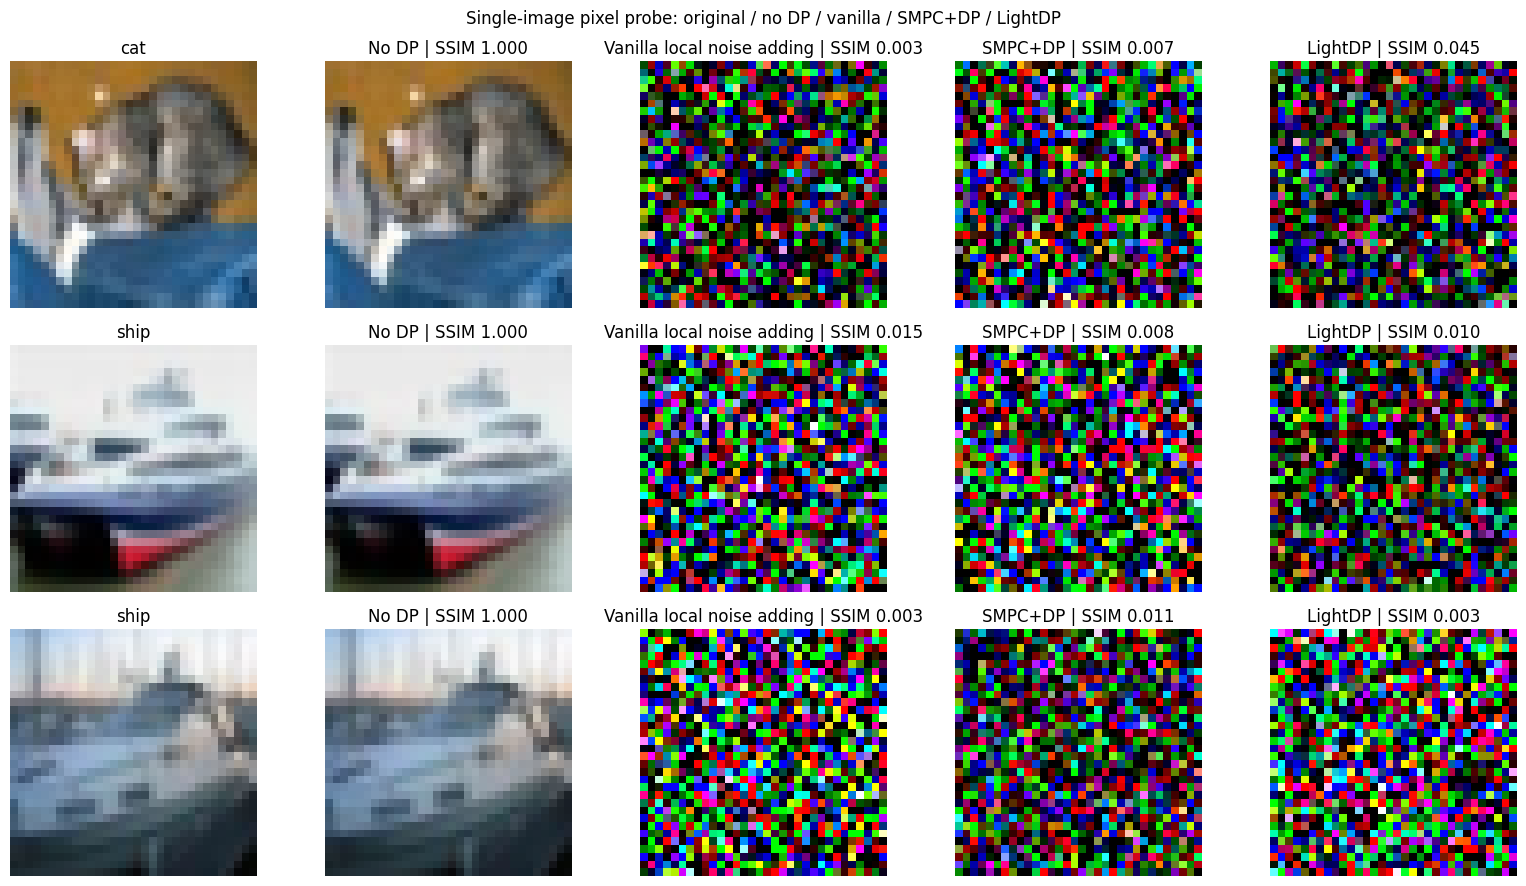

,image_id,method,mse,psnr,ssim
0,0,No DP,3.350727e-16,150.000000,1.000000
1,0,Vanilla local noise adding,1.683724e-01,7.737291,0.002752
2,0,SMPC+DP,1.773515e-01,7.511650,0.006666
3,0,LightDP,1.599501e-01,7.960155,0.045089
4,1,No DP,1.023907e-15,149.897395,1.000000
5,1,Vanilla local noise adding,3.242343e-01,4.891410,0.015170
6,1,SMPC+DP,3.399654e-01,4.685653,0.007998
7,1,LightDP,3.444039e-01,4.629319,0.010243
8,2,No DP,5.868786e-16,150.000000,1.000000
9,2,Vanilla local noise adding,2.598864e-01,5.852164,0.002668


In [4]:
ATTACK_IDS=[0,1,2]
probe_cal=calibrate(4.0,1,2*CFG['clip'])
H=CFG['n_clients']-CFG['max_colluders']
probe_light_var=1/precision_diag(probe_cal['u'],probe_cal['k'],H,0)
probe=nn.Linear(3072,10).to(DEVICE)
probe_rows=[]
fig,axs=plt.subplots(len(ATTACK_IDS),5,figsize=(16,9))
for row,idx in enumerate(ATTACK_IDS):
    x=transforms.ToTensor()(raw_test[idx][0]).to(DEVICE)
    label=torch.tensor([raw_test[idx][1]],device=DEVICE)
    gw,gb=torch.autograd.grad(F.cross_entropy(probe(x.flatten()[None]),label),tuple(probe.parameters()))
    scale=(CFG['clip']/torch.sqrt(gw.square().sum()+gb.square().sum())).clamp(max=1)
    clean=torch.cat([(gw*scale).flatten(),gb*scale])
    original=x.permute(1,2,0).cpu().numpy()
    axs[row,0].imshow(original); axs[row,0].set_title(raw_test.classes[label.item()])
    for col,(name,var) in enumerate([('No DP',0),('Vanilla local noise adding',probe_cal['normal_var']),('SMPC+DP',probe_cal['normal_var']),('LightDP',probe_light_var)],1):
        obs=clean+math.sqrt(var)*torch.randn_like(clean)
        w=obs[:30720].view(10,3072); b=obs[30720:]
        j=b.abs().argmax()
        recovered=(w[j]/b[j].clamp(min=1e-12) if b[j]>=0 else w[j]/b[j].clamp(max=-1e-12))
        recovered=recovered.view(3,32,32).clamp(0,1).permute(1,2,0).cpu().numpy()
        mse=float(np.mean((original-recovered)**2))
        ssim=structural_similarity(original,recovered,channel_axis=2,data_range=1)
        probe_rows.append(dict(image_id=idx,method=name,mse=mse,psnr=-10*np.log10(max(mse,1e-15)),ssim=ssim))
        axs[row,col].imshow(recovered); axs[row,col].set_title(f'{name} | SSIM {ssim:.3f}')
for ax in axs.flat: ax.axis('off')
fig.suptitle('Single-image pixel probe: original / no DP / vanilla / SMPC+DP / LightDP')
fig.tight_layout(); fig.savefig(OUT/'00_exact_pixel_reconstruction.png',dpi=180); plt.show()
probe_df=pd.DataFrame(probe_rows); probe_df.to_csv(OUT/'pixel_attack.csv',index=False)
display(probe_df)
assert probe_df.query("method == 'No DP'").mse.max()<1e-8


## Trainable image model and correct record clipping

The trainable branch uses three convolutions (16/32/32 channels) and a 64-dimensional image representation. It combines this with the 512-dimensional public feature. All branch and classifier parameters are updated. This is more substantial than v1's linear head, while keeping per-example DP gradients manageable.

Per-example gradients are computed using [`torch.func.vmap(grad(...))`](https://docs.pytorch.org/tutorials/intermediate/per_sample_grads.html). Every complete per-example gradient is clipped before client averaging. A chunk of 32 only controls memory; sensitivity remains **2C / client_dataset_size**. No BatchNorm statistics are fitted on private records. During attacks, the cached-feature path is replaced by the differentiable public backbone so reconstruction really uses the same input-to-output model.


In [5]:
class HybridClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch=nn.Sequential(nn.Conv2d(3,16,3,padding=1),nn.SiLU(),nn.AvgPool2d(2),
                                  nn.Conv2d(16,32,3,padding=1),nn.SiLU(),nn.AvgPool2d(2),
                                  nn.Conv2d(32,32,3,padding=1),nn.SiLU(),nn.AdaptiveAvgPool2d((2,2)),
                                  nn.Flatten(),nn.Linear(128,64),nn.SiLU())
        self.head=nn.Linear(512+64,10)
        nn.init.normal_(self.head.weight,std=.01);nn.init.zeros_(self.head.bias)
    def forward(self,pixels,public):
        learned=self.branch((pixels-.5)/.5)
        learned=F.normalize(learned,dim=-1)
        return self.head(torch.cat([public,learned],dim=-1))

torch.manual_seed(SEED)
model=HybridClassifier().to(DEVICE)
initial={k:v.detach().clone() for k,v in model.named_parameters()}
buffers=dict(model.named_buffers())
names=list(initial);shapes=[initial[k].shape for k in names];sizes=[initial[k].numel() for k in names]
P=sum(sizes)
def pack(params): return torch.cat([params[k].reshape(-1) for k in names])
def unpack(vector):
    return {k:v.view(shape) for k,v,shape in zip(names,vector.split(sizes),shapes)}
def one_loss(params,buffers,x,feat,y):
    logits=functional_call(model,(params,buffers),(x[None],feat[None]))
    return F.cross_entropy(logits,y[None])
per_example=vmap(grad(one_loss),in_dims=(None,None,0,0,0),randomness='error')

def clipped_chunk(params,x,feat,y,C):
    grads=per_example(params,buffers,x,feat,y)
    flat=torch.cat([grads[k].flatten(1) for k in names],dim=1)
    norm=flat.norm(dim=1).clamp_min(1e-12)
    factors=(C/norm).clamp(max=1)
    return (flat*factors[:,None]).sum(0).detach()

@torch.no_grad()
def accuracy(params):
    correct=0
    for start in range(0,len(test_pixels),256):
        x=test_pixels[start:start+256].to(DEVICE)
        f=test_features[start:start+256].to(DEVICE)
        y=test_labels[start:start+256].to(DEVICE)
        output=functional_call(model,(params,buffers),(x,f))
        correct+=output.argmax(1).eq(y).sum().item()
    return 100*correct/len(test_pixels)

def partition(N,skew=False):
    rng=np.random.default_rng(SEED)
    order=rng.permutation(len(train_labels))
    if skew:
        order=order[np.argsort(train_labels.numpy()[order],kind='stable')]
        shards=np.array_split(order,2*N); rng.shuffle(shards)
        return [np.concatenate(shards[2*i:2*i+2]) for i in range(N)]
    return list(order.reshape(N,-1))

def client_gradient(params,ids,round_id,C):
    total=torch.zeros(P,device=DEVICE)
    view=round_id%2
    for start in range(0,len(ids),CFG['microbatch']):
        ii=torch.as_tensor(ids[start:start+CFG['microbatch']])
        x=train_pixels[ii].to(DEVICE)
        if view: x=x.flip(-1)
        f=train_features[view,ii].to(DEVICE);y=train_labels[ii].to(DEVICE)
        total+=clipped_chunk(params,x,f,y,C)
    return total/len(ids)

sx=torch.rand(2,3,32,32,device=DEVICE); sf=F.normalize(torch.randn(2,512,device=DEVICE),dim=1)
sy=torch.tensor([0,1],device=DEVICE)
functional=clipped_chunk(initial,sx,sf,sy,1.)
manual=[]
pp={k:v.clone().requires_grad_(True) for k,v in initial.items()}
for i in range(2):
    gg=torch.autograd.grad(one_loss(pp,buffers,sx[i],sf[i],sy[i]),tuple(pp.values()))
    vector=torch.cat([g.flatten() for g in gg]); manual.append(vector*min(1.,1/vector.norm().item()))
assert torch.allclose(functional,torch.stack(manual).sum(0),atol=3e-5,rtol=3e-4)
print(f'PASS: complete per-example clipping; {P:,} trainable parameters.')


PASS: complete per-example clipping; 28,362 trainable parameters.


## Timing pilot and automatic round budget

The pilot times **synthetic** gradient chunks, GPU noise and evaluation. It does not train on private images or select hyperparameters using private accuracy. Requested main rounds are 50; the available budget is divided between ten main runs and ten shorter controlled sweep runs. The actual selected numbers, predicted duration and effective image passes are printed below **before privacy calibration**.

If the hardware cannot support at least 5 main rounds and 3 sweep rounds, the notebook stops with a clear message instead of silently doing an uninformative experiment. If the machine speeds up, it can finish early. If hardware slows down, rerun to resume saved progress rather than changing the calibrated round count midway. No artificial sleeps are used.

The selected plan is cached. Subsequent executions reuse it so available time does not silently change noise calibration. Checkpoints save every five rounds; interrupted runs resume from the last saved round. Full planned runs are completed rather than applying a new elapsed-time cutoff on each rerun. Hardware slowdowns can exceed the time estimate.


In [6]:
SWEEP_COUNT=10
MAIN_COUNT=10
PLAN_KEY=digest(dict(requested_main=CFG['requested_main_rounds'],requested_sweep=CFG['requested_sweep_rounds'],
                     minutes=CFG['target_minutes'],reserve=CFG['diagnostic_reserve_minutes'],
                     Nmain=MAIN_COUNT,Nsweep=SWEEP_COUNT,data=DATA_KEY,features=FEATURE_KEY,
                     model=cache_source(HybridClassifier),clipping=cache_source(clipped_chunk),
                     microbatch=CFG['microbatch'],gpu=torch.cuda.get_device_name()))
plan_file=cache_path('plans',PLAN_KEY)
if plan_file.exists():
    plan=read_cache(plan_file)
    MAIN_ROUNDS=plan['main_rounds'];SWEEP_ROUNDS=plan['sweep_rounds']
    print('CACHE HIT: stable round plan; timing pilot skipped.')
else:
    sx=torch.rand(CFG['microbatch'],3,32,32,device=DEVICE)
    sf=F.normalize(torch.randn(CFG['microbatch'],512,device=DEVICE),dim=1)
    sy=torch.randint(0,10,(CFG['microbatch'],),device=DEVICE)
    for _ in range(2): clipped_chunk(initial,sx,sf,sy,CFG['clip'])
    sync();pilot_start=time.monotonic()
    for _ in range(8): clipped_chunk(initial,sx,sf,sy,CFG['clip'])
    sync();chunk_seconds=(time.monotonic()-pilot_start)/8

    sync();pilot_start=time.monotonic();accuracy(initial);sync()
    eval_seconds=time.monotonic()-pilot_start
    round_seconds=chunk_seconds*math.ceil(CFG['train_size']/CFG['microbatch'])*1.35 + eval_seconds + .3
    available=max(0,remaining_minutes()-CFG['diagnostic_reserve_minutes'])*60
    ratio=CFG['requested_sweep_rounds']/CFG['requested_main_rounds']
    MAIN_ROUNDS=min(CFG['requested_main_rounds'],int(available/(round_seconds*(MAIN_COUNT+SWEEP_COUNT*ratio))))
    SWEEP_ROUNDS=min(CFG['requested_sweep_rounds'],max(3,int(MAIN_ROUNDS*ratio)))
    while MAIN_ROUNDS>=5 and available<round_seconds*(MAIN_COUNT*MAIN_ROUNDS+SWEEP_COUNT*SWEEP_ROUNDS):
        MAIN_ROUNDS-=1
        SWEEP_ROUNDS=min(CFG['requested_sweep_rounds'],max(3,int(MAIN_ROUNDS*ratio)))
    assert MAIN_ROUNDS>=5, 'GPU too slow for this budget. Increase target_minutes or reduce the sweep list and update SWEEP_COUNT.'
    planned_seconds=round_seconds*(MAIN_COUNT*MAIN_ROUNDS+SWEEP_COUNT*SWEEP_ROUNDS)
    plan=dict(main_rounds=MAIN_ROUNDS,sweep_rounds=SWEEP_ROUNDS,
              estimated_round_seconds=round_seconds,predicted_training_minutes=planned_seconds/60,
              microbatch=CFG['microbatch'],main_images_per_method=MAIN_ROUNDS*50000,
              main_record_passes=MAIN_ROUNDS,feature_preparation_minutes=feature_seconds/60,
              planned_total_minutes=(time.monotonic()-START)/60+planned_seconds/60+CFG['diagnostic_reserve_minutes'])

    save_cache(plan_file,plan)
display(pd.Series(plan,name='Actual runtime plan'))
(OUT/'runtime_plan.json').write_text(json.dumps(plan,indent=2))


CACHE HIT: stable round plan; timing pilot skipped.


,Actual runtime plan
main_rounds,8.000000
sweep_rounds,3.000000
estimated_round_seconds,46.451345
predicted_training_minutes,85.160800
microbatch,32.000000
main_images_per_method,400000.000000
main_record_passes,8.000000
feature_preparation_minutes,5.573548
planned_total_minutes,106.200990


324

## Main comparison: no DP, independent DP, LightDP

All methods use the same initialization, full data, view schedule, dropout schedule, clipping norm, learning rate and completed rounds. The Gaussian sampler uses the exact covariance of explicit pairwise masks, avoiding the storage of all pairwise vectors; later we separately benchmark actual streaming pairwise generation.

Measured components: local gradient computation, masking + averaging, evaluation, round wall time, peak allocated/reserved GPU memory and sampled host process RSS. **These are a sequential single-GPU simulator's costs, not distributed client latency.** Common feature extraction is counted separately. GPU synchronization surrounds timings. Intermediate accuracy logging is kept to every fifth round.


In [7]:
def make_run(tag,method,rounds,eps=6.,N=None,Cmax=None,Smax=None,C=None,lr=None,skew=False):
    N=CFG['n_clients'] if N is None else N
    Cmax=CFG['max_colluders'] if Cmax is None else Cmax
    Smax=CFG['max_stragglers'] if Smax is None else Smax
    C=CFG['clip'] if C is None else C
    lr=CFG['lr'] if lr is None else lr
    assert N>Cmax+Smax and 0<=Smax<N and 50000%N==0
    sensitivity=2*C/(50000//N)
    cal=None if method=='No DP' else calibrate(eps,rounds,sensitivity,N,Cmax,Smax)
    return dict(tag=tag,method=method,planned_rounds=rounds,eps=eps,N=N,Cmax=Cmax,Smax=Smax,C=C,lr=lr,skew=skew,
                params={k:v.clone() for k,v in initial.items()},velocity=torch.zeros(P,device=DEVICE),
                cal=cal,parts=partition(N,skew),generator=torch.Generator(device=DEVICE).manual_seed(SEED+33),
                local_seconds=0.,mask_seconds=0.,eval_seconds=0.,train_seconds=0.,
                peak_allocated_MiB=0.,peak_reserved_MiB=0.,host_RSS_MiB=0.,completed=0,measurement_gpu=torch.cuda.get_device_name())

history=[];timing_rows=[]
def step_run(run,t):
    torch.cuda.reset_peak_memory_stats();sync();started=time.monotonic()
    local_start=started
    clean=torch.stack([client_gradient(run['params'],ids,t,run['C']) for ids in run['parts']])
    sync();local_seconds=time.monotonic()-local_start
    rng=np.random.default_rng(SEED+1000+t)
    s=int(rng.integers(run['Smax']+1));active=rng.choice(run['N'],run['N']-s,replace=False)
    sync();mask_start=time.monotonic()
    if run['method']=='Vanilla local noise adding':
        clean=clean+math.sqrt(run['cal']['normal_var'])*torch.randn(clean.shape,device=DEVICE,generator=run['generator'])
    elif run['method']=='SMPC+DP':
        hmin=run['N']-run['Cmax']-run['Smax']
        clean=clean+math.sqrt(run['cal']['normal_var']/hmin)*torch.randn(clean.shape,device=DEVICE,generator=run['generator'])
    elif run['method']=='LightDP':
        clean=clean+joint_noise(run['N'],P,run['cal']['u'],run['cal']['k'],run['generator'])
    gradient=clean[torch.as_tensor(active,device=DEVICE)].mean(0)
    with torch.no_grad():
        run['velocity'].mul_(CFG['momentum']).add_(gradient)
        lr=run['lr']*(.2+.8*(1+math.cos(math.pi*t/run['planned_rounds']))/2)
        vector=pack(run['params'])-lr*run['velocity']
        run['params']={k:v.detach() for k,v in unpack(vector).items()}
    sync();mask_seconds=time.monotonic()-mask_start
    elapsed=time.monotonic()-started
    assert torch.isfinite(vector).all(), f'Nonfinite model: {run["tag"]}'
    run['local_seconds']+=local_seconds;run['mask_seconds']+=mask_seconds;run['train_seconds']+=elapsed
    run['completed']=t+1
    run['peak_allocated_MiB']=max(run['peak_allocated_MiB'],torch.cuda.max_memory_allocated()/2**20)
    run['peak_reserved_MiB']=max(run['peak_reserved_MiB'],torch.cuda.max_memory_reserved()/2**20)
    run['host_RSS_MiB']=max(run['host_RSS_MiB'],psutil.Process().memory_info().rss/2**20)
    timing_rows.append(dict(run=run['tag'],round=t+1,local_seconds=local_seconds,mask_seconds=mask_seconds,wall_seconds=elapsed,stragglers=s))

def log_run(run):
    sync();ts=time.monotonic();acc=accuracy(run['params']);sync();run['eval_seconds']+=time.monotonic()-ts
    eps=np.inf if run['cal'] is None else eps_from_rho(run['completed']*run['cal']['rho_round'],CFG['delta'])
    history.append(dict(run=run['tag'],method=run['method'],round=run['completed'],accuracy=acc,epsilon=eps,
                        training_seconds=run['train_seconds'],N=run['N'],Cmax=run['Cmax'],Smax=run['Smax'],clip=run['C'],lr=run['lr']))
    print(f'{run["tag"]}: round {run["completed"]}/{run["planned_rounds"]}, acc={acc:.2f}%, elapsed train={run["train_seconds"]/60:.1f} min',flush=True)


TRAIN_CODE_KEY=digest(dict(model=cache_source(HybridClassifier),
                          training=cache_source(step_run),make=cache_source(make_run),
                          clipping=cache_source(clipped_chunk),sample=cache_source(one_loss),
                          clients=cache_source(client_gradient),partition=cache_source(partition),
                          noise=cache_source(joint_noise),calibration=cache_source(calibrate),
                          precision=cache_source(precision_diag),rho=cache_source(rho_from_eps),
                          states=cache_source(configurations),pack=cache_source(pack),unpack=cache_source(unpack),
                          torch=torch.__version__,vision=torchvision.__version__))
def run_key(run):
    settings={k:run[k] for k in ['method','planned_rounds','eps','N','Cmax','Smax','C','lr','skew']}
    if run['method']=='No DP':settings.pop('eps')
    return digest(dict(settings=settings,seed=SEED,momentum=CFG['momentum'],delta=CFG['delta'],
                       microbatch=CFG['microbatch'],features=FEATURE_KEY,code=TRAIN_CODE_KEY,
                       initialization=tensor_digest(pack(initial))))

def checkpoint(run):
    data=dict(params={k:v.cpu() for k,v in run['params'].items()},velocity=run['velocity'].cpu(),
              completed=run['completed'],planned_rounds=run['planned_rounds'],calibration=run['cal'],
              noise_rng=run['generator'].get_state(),
              stats={k:run[k] for k in ['local_seconds','mask_seconds','eval_seconds','train_seconds','peak_allocated_MiB','peak_reserved_MiB','host_RSS_MiB','measurement_gpu']},
              history=list({h['round']:h for h in history if h['run']==run['tag']}.values()),
              timings=list({h['round']:h for h in timing_rows if h['run']==run['tag']}.values()),cache_key=run_key(run))
    save_cache(cache_path('training',run_key(run)),data)
    torch.save(data,OUT/(run['tag'].replace(' ','_')+'.pt'))

def restore(run):
    path=cache_path('training',run_key(run))
    if not path.exists():return
    data=read_cache(path)
    assert data['cache_key']==run_key(run)
    run['params']={k:v.to(DEVICE) for k,v in data['params'].items()}
    run['velocity']=data['velocity'].to(DEVICE)
    run['generator'].set_state(data['noise_rng'])
    run['completed']=data['completed'];run.update(data['stats'])
    history.extend([dict(h,run=run['tag']) for h in data['history']])
    timing_rows.extend([dict(h,run=run['tag']) for h in data['timings']])
    print(f'CACHE HIT {run["tag"]}: {run["completed"]}/{run["planned_rounds"]} rounds; recorded times are original measurements.')

def execute_group(runs):
    tags={r['tag'] for r in runs}
    history[:]=[h for h in history if h['run'] not in tags]
    timing_rows[:]=[h for h in timing_rows if h['run'] not in tags]
    for run in runs:restore(run)
    for t in range(runs[0]['planned_rounds']):
        for run in runs:
            if run['completed']>t:continue
            step_run(run,t);log_run(run)
            if (t+1)%5==0 or t+1==run['planned_rounds']:checkpoint(run)
        pd.DataFrame(history).to_csv(OUT/'history.csv',index=False)
    for run in runs:checkpoint(run)

private_methods=['Vanilla local noise adding','SMPC+DP','LightDP']
main=[make_run('No DP','No DP',MAIN_ROUNDS)]
main += [make_run(f'{method}_eps{eps:g}',method,MAIN_ROUNDS,eps=eps)
         for eps in [3.,6.,9.] for method in private_methods]
execute_group(main)
MAIN_COMPLETED=MAIN_ROUNDS
main_all=main
main=[main_all[0]]+[next(r for r in main_all if r['method']==m and r['eps']==6.) for m in private_methods]
print('Common completed main rounds:',MAIN_COMPLETED)


CACHE HIT No DP: 8/8 rounds; recorded times are original measurements.
CACHE HIT Vanilla local noise adding_eps3: 8/8 rounds; recorded times are original measurements.
CACHE HIT SMPC+DP_eps3: 8/8 rounds; recorded times are original measurements.
CACHE HIT LightDP_eps3: 8/8 rounds; recorded times are original measurements.
CACHE HIT Vanilla local noise adding_eps6: 8/8 rounds; recorded times are original measurements.
CACHE HIT SMPC+DP_eps6: 8/8 rounds; recorded times are original measurements.
CACHE HIT LightDP_eps6: 8/8 rounds; recorded times are original measurements.
CACHE HIT Vanilla local noise adding_eps9: 8/8 rounds; recorded times are original measurements.
CACHE HIT SMPC+DP_eps9: 8/8 rounds; recorded times are original measurements.
CACHE HIT LightDP_eps9: 8/8 rounds; recorded times are original measurements.
Common completed main rounds: 8


## Controlled parameter comparisons (all start from initialization)

Ten LightDP runs: reference, ε=3, ε=9, N=25, N=100, collusion bound 20, straggler bound 20, clipping 0.5, learning rate 0.05, and non-IID shards. **Only the named parameter changes**. For client count, changing records/client also changes the sensitivity and hence noise; that is part of this experiment. Each run has fresh, correctly recalibrated noise. The common shorter training length is a screening experiment, not converged evidence or a parameter optimum.

Non-IID labels determine the illustrative partition before the protocol. Its reported DP bound is **conditional on fixed client membership** and does not privatize the partitioning operation. All runs have the same total record count. Randomness is seeded for reproducibility, but this is not a multi-seed confidence interval.


CACHE HIT Sweep_Reference: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_epsilon_3: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_epsilon_9: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_clients_25: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_clients_100: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_colluders_20: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_stragglers_20: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_clip_0.5: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_lr_0.05: 3/3 rounds; recorded times are original measurements.
CACHE HIT Sweep_nonIID: 3/3 rounds; recorded times are original measurements.


,round,accuracy,epsilon,N,Cmax,Smax,clip,lr
run,,,,,,,,
Sweep_clip_0.5,3,15.03,6.0,50,10,10,0.5,1.00
Sweep_clients_100,3,38.04,6.0,100,10,10,1.0,1.00
Sweep_clients_25,3,34.83,6.0,25,10,10,1.0,1.00
Sweep_Reference,3,42.65,6.0,50,10,10,1.0,1.00
Sweep_epsilon_9,3,42.84,9.0,50,10,10,1.0,1.00
Sweep_epsilon_3,3,42.18,3.0,50,10,10,1.0,1.00
Sweep_stragglers_20,3,41.53,6.0,50,10,20,1.0,1.00
Sweep_colluders_20,3,42.68,6.0,50,20,10,1.0,1.00
Sweep_nonIID,3,26.20,6.0,50,10,10,1.0,1.00


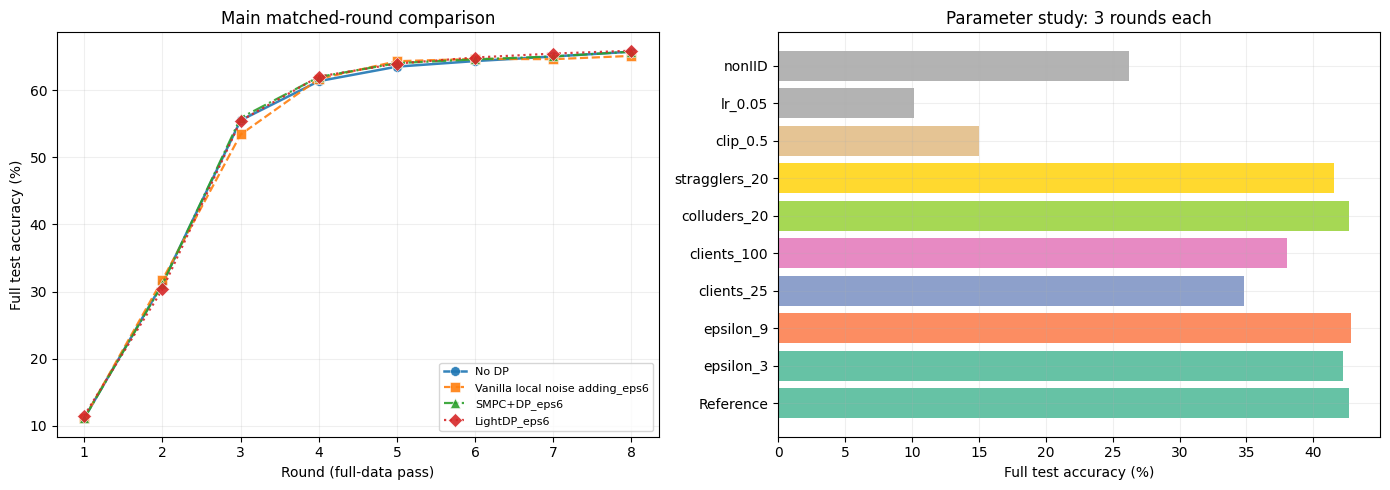

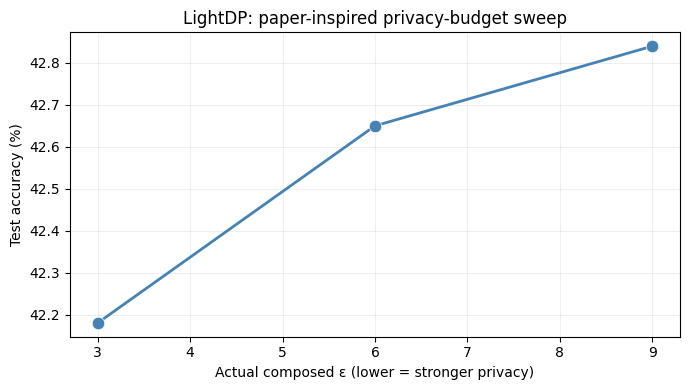

In [8]:
sweep_specs=[('Reference',{}),('epsilon_3',dict(eps=3.)),('epsilon_9',dict(eps=9.)),
             ('clients_25',dict(N=25)),('clients_100',dict(N=100)),
             ('colluders_20',dict(Cmax=20)),('stragglers_20',dict(Smax=20)),
             ('clip_0.5',dict(C=.5)),('lr_0.05',dict(lr=.05)),('nonIID',dict(skew=True))]
assert len(sweep_specs)==SWEEP_COUNT
sweeps=[make_run('Sweep_'+name,'LightDP',SWEEP_ROUNDS,**changes) for name,changes in sweep_specs]
execute_group(sweeps)
all_runs=main_all+sweeps
hist=pd.DataFrame(history);hist.to_csv(OUT/'history.csv',index=False)
pd.DataFrame(timing_rows).to_csv(OUT/'round_timings.csv',index=False)
last=hist.sort_values('round').groupby('run',sort=False).tail(1).set_index('run')
display(last[['round','accuracy','epsilon','N','Cmax','Smax','clip','lr']])
fig,axs=plt.subplots(1,2,figsize=(14,5))
main_styles=[('o','-','tab:blue',1.8,7),('s','--','tab:orange',1.6,7),('^','-.','tab:green',1.6,7),('D',':','tab:red',1.6,7)]
for i,run in enumerate(main):
    part=hist[hist.run==run['tag']]
    mk,ls,clr,lw,ms=main_styles[i%len(main_styles)]
    axs[0].plot(part['round'],part.accuracy,marker=mk,linestyle=ls,color=clr,linewidth=lw,markersize=ms,
                markeredgecolor='white',markeredgewidth=0.4,label=run['tag'],alpha=0.9)
axs[0].set(xlabel='Round (full-data pass)',ylabel='Full test accuracy (%)',title='Main matched-round comparison');axs[0].legend(fontsize=8)
tags=[r['tag'] for r in sweeps]
colors=plt.cm.Set2(np.linspace(0,1,len(tags)))
axs[1].barh([t.replace('Sweep_','') for t in tags],last.loc[tags,'accuracy'],color=colors)
axs[1].set(xlabel='Full test accuracy (%)',title=f'Parameter study: {sweeps[0]["completed"]} rounds each')
for ax in axs:ax.grid(alpha=.2)
fig.tight_layout();fig.savefig(OUT/'01_accuracy_and_parameter_comparison.png',dpi=180);plt.show()
fig,ax=plt.subplots(figsize=(7,4))
eps_tags=['Sweep_epsilon_3','Sweep_Reference','Sweep_epsilon_9']
ax.plot(last.loc[eps_tags,'epsilon'],last.loc[eps_tags,'accuracy'],'o-',markersize=9,linewidth=2,
        markerfacecolor='steelblue',markeredgecolor='white',markeredgewidth=0.5,color='steelblue')
ax.set(xlabel='Actual composed \u03b5 (lower = stronger privacy)',ylabel='Test accuracy (%)',title='LightDP: paper-inspired privacy-budget sweep')
ax.grid(alpha=.2);fig.tight_layout();fig.savefig(OUT/'02_epsilon_tradeoff.png',dpi=180);plt.show()


## Paper-style three-panel output: ε=3,6,9

Blue circles: LightDP. Green squares: Vanilla local noise adding. Red triangles: SMPC+DP. Each panel uses actual **full-test accuracy versus communication round**, on a 0–1 accuracy scale like the paper. Every curve has the same planned/completed round count, common initialization and matched total ε within the panel. Curves are not smoothed or forced into the published ordering. The separate no-DP comparison remains above.


In [34]:
# fig=plt.figure(figsize=(12,9))
# gs=fig.add_gridspec(2,4,hspace=.5,wspace=.8)
# axes=[fig.add_subplot(gs[0,:2]),fig.add_subplot(gs[0,2:]),fig.add_subplot(gs[1,1:3])]
# styles={'LightDP':('blue','o','-','The proposed LightDP-FL scheme'),
#         'Vanilla local noise adding':('olivedrab','s','--','Vanilla local noise adding'),
#         'SMPC+DP':('orangered','^','-.','SMPC+DP (ideal aggregation)')}
# for ax,eps,letter in zip(axes,[3.,6.,9.],['a','b','c']):
#     all_acc=[]
#     for method,(color,marker,ls,label) in styles.items():
#         part=hist[hist.run==f'{method}_eps{eps:g}'].sort_values('round')
#         acc_vals=(part.accuracy/100).tolist()
#         all_acc.extend(acc_vals)
#         ax.plot(part['round'],part.accuracy/100,color=color,marker=marker,markersize=7,
#                 markerfacecolor=color,markeredgecolor='white',markeredgewidth=0.5,
#                 linewidth=1.8,linestyle=ls,label=label,alpha=0.9)
#     ax.set(xlabel='Communication Round',ylabel='Test Accuracy',xlim=(1,max(2,MAIN_ROUNDS)))
#     # Auto-scale Y to data range with padding for clear line separation
#     if all_acc:
#         ymin,ymax=min(all_acc),max(all_acc)
#         pad=max(0.03,(ymax-ymin)*0.4)
#         ax.set_ylim(max(0,ymin-pad),min(1,ymax+pad))
#     ax.set_title(f'({letter}) \u03b5 = {eps:g}',y=-.32,fontsize=15)
#     ax.grid(alpha=.15);ax.legend(fontsize=8,loc='lower right')
# fig.suptitle('Measured CIFAR-10 comparison \u2014 matched privacy and training length',fontsize=13)
# fig.savefig(OUT/'07_paper_style_epsilon_comparison.png',dpi=220,bbox_inches='tight');plt.show()


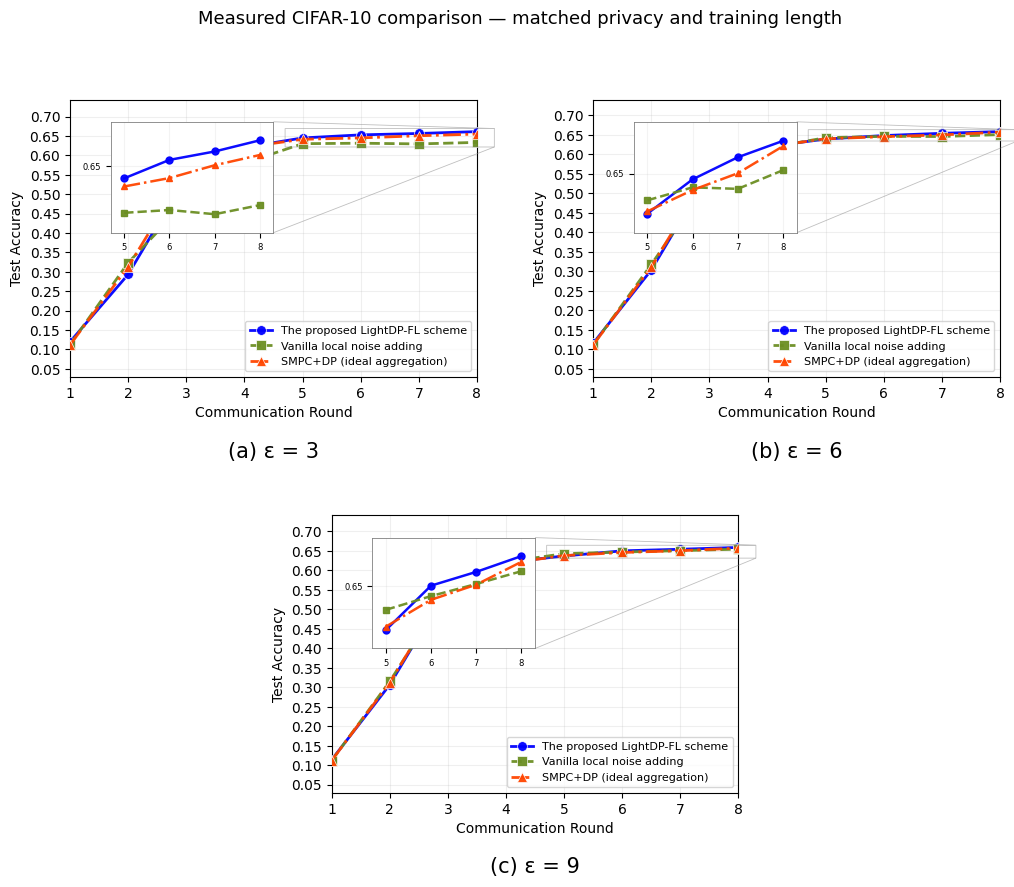

In [31]:
from matplotlib.ticker import MultipleLocator

fig=plt.figure(figsize=(12,9))
gs=fig.add_gridspec(2,4,hspace=.5,wspace=.8)
axes=[fig.add_subplot(gs[0,:2]),fig.add_subplot(gs[0,2:]),fig.add_subplot(gs[1,1:3])]
styles={'LightDP':('blue','o','-','The proposed LightDP-FL scheme'),
        'Vanilla local noise adding':('olivedrab','s','--','Vanilla local noise adding'),
        'SMPC+DP':('orangered','^','-.','SMPC+DP (ideal aggregation)')}

for ax,eps,letter in zip(axes,[3.,6.,9.],['a','b','c']):
    all_acc=[]
    parts={}
    for method,(color,marker,ls,label) in styles.items():
        part=hist[hist.run==f'{method}_eps{eps:g}'].sort_values('round')
        parts[method]=part
        acc_vals=(part.accuracy/100).tolist()
        all_acc.extend(acc_vals)
        ax.plot(part['round'],part.accuracy/100,color=color,marker=marker,markersize=7,
                markerfacecolor=color,markeredgecolor='white',markeredgewidth=0.5,
                linewidth=2,linestyle=ls,label=label,alpha=0.95,zorder=3)

    ax.set(xlabel='Communication Round',ylabel='Test Accuracy',xlim=(1,max(2,MAIN_ROUNDS)))
    if all_acc:
        ymin,ymax=min(all_acc),max(all_acc)
        pad=max((ymax-ymin)*0.15,0.02)
        ax.set_ylim(ymin-pad,ymax+pad)

    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.2f}'))

    ax.set_title(f'({letter}) \u03b5 = {eps:g}',y=-.32,fontsize=15)
    ax.grid(alpha=.2);ax.legend(fontsize=8,loc='lower right')

    x0 = max(1, MAIN_ROUNDS-3)
    axins = ax.inset_axes([0.10, 0.52, 0.40, 0.40])

    tail_acc=[]
    for method,(color,marker,ls,label) in styles.items():
        p=parts[method]
        tail=p[p['round']>=x0]
        if tail.empty:
            continue
        tail_acc.extend((tail.accuracy/100).tolist())
        axins.plot(tail['round'],tail.accuracy/100,color=color,marker=marker,
                   markersize=5,linewidth=1.8,linestyle=ls,alpha=0.95,zorder=3)

    if tail_acc:
        tmin,tmax=min(tail_acc),max(tail_acc)
        tpad=max((tmax-tmin)*0.25,0.005)
        axins.set_xlim(x0-0.3, MAIN_ROUNDS+0.3)
        axins.set_ylim(tmin-tpad, tmax+tpad)

    axins.yaxis.set_major_locator(MultipleLocator(0.05))
    axins.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.2f}'))

    axins.tick_params(labelsize=6)
    axins.set_facecolor('white')
    axins.grid(alpha=.15)
    for spine in axins.spines.values():
        spine.set_edgecolor('gray'); spine.set_linewidth(0.6)

    ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5, linewidth=0.6)

fig.suptitle('Measured CIFAR-10 comparison \u2014 matched privacy and training length',fontsize=13)
fig.savefig(OUT/'07_paper_style_epsilon_comparison.png',dpi=220,bbox_inches='tight')
plt.show()

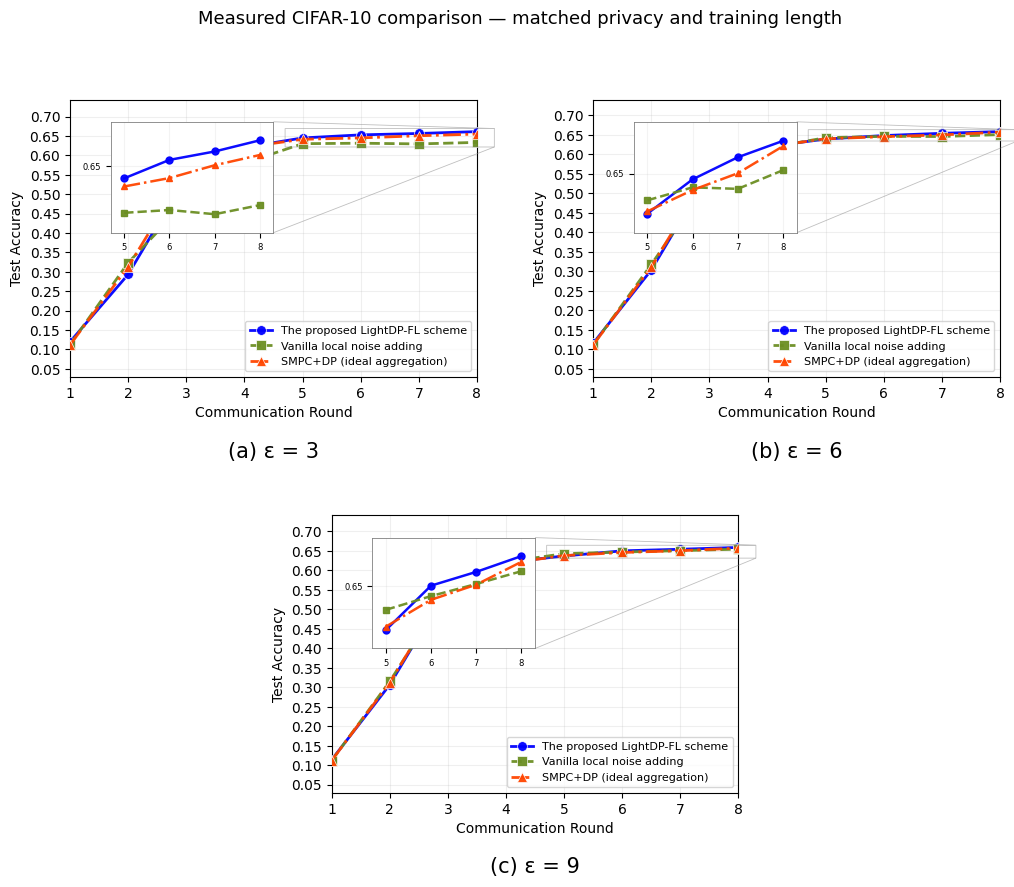

In [37]:
from matplotlib.ticker import MultipleLocator

fig=plt.figure(figsize=(12,9))
gs=fig.add_gridspec(2,4,hspace=.5,wspace=.8)
axes=[fig.add_subplot(gs[0,:2]),fig.add_subplot(gs[0,2:]),fig.add_subplot(gs[1,1:3])]
styles={'LightDP':('blue','o','-','The proposed LightDP-FL scheme'),
        'Vanilla local noise adding':('olivedrab','s','--','Vanilla local noise adding'),
        'SMPC+DP':('orangered','^','-.','SMPC+DP (ideal aggregation)')}

for ax,eps,letter in zip(axes,[3.,6.,9.],['a','b','c']):
    all_acc=[]
    parts={}
    for method,(color,marker,ls,label) in styles.items():
        part=hist[hist.run==f'{method}_eps{eps:g}'].sort_values('round')
        parts[method]=part
        acc_vals=(part.accuracy/100).tolist()
        all_acc.extend(acc_vals)
        ax.plot(part['round'],part.accuracy/100,color=color,marker=marker,markersize=7,
                markerfacecolor=color,markeredgecolor='white',markeredgewidth=0.5,
                linewidth=2,linestyle=ls,label=label,alpha=0.95,zorder=3)

    ax.set(xlabel='Communication Round',ylabel='Test Accuracy',xlim=(1,max(2,MAIN_ROUNDS)))
    if all_acc:
        ymin,ymax=min(all_acc),max(all_acc)
        pad=max((ymax-ymin)*0.15,0.02)
        ax.set_ylim(ymin-pad,ymax+pad)

    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.2f}'))

    ax.set_title(f'({letter}) \u03b5 = {eps:g}',y=-.32,fontsize=15)
    ax.grid(alpha=.2);ax.legend(fontsize=8,loc='lower right')

    x0 = max(1, MAIN_ROUNDS-3)
    axins = ax.inset_axes([0.10, 0.52, 0.40, 0.40])

    tail_acc=[]
    for method,(color,marker,ls,label) in styles.items():
        p=parts[method]
        tail=p[p['round']>=x0]
        if tail.empty:
            continue
        tail_acc.extend((tail.accuracy/100).tolist())
        axins.plot(tail['round'],tail.accuracy/100,color=color,marker=marker,
                   markersize=5,linewidth=1.8,linestyle=ls,alpha=0.95,zorder=3)

    if tail_acc:
        tmin,tmax=min(tail_acc),max(tail_acc)
        tpad=max((tmax-tmin)*0.25,0.005)
        axins.set_xlim(x0-0.3, MAIN_ROUNDS+0.3)
        axins.set_ylim(tmin-tpad, tmax+tpad)

    axins.yaxis.set_major_locator(MultipleLocator(0.05))
    axins.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.2f}'))

    axins.tick_params(labelsize=6)
    axins.set_facecolor('white')
    axins.grid(alpha=.15)
    for spine in axins.spines.values():
        spine.set_edgecolor('gray'); spine.set_linewidth(0.6)

    ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5, linewidth=0.6)

fig.suptitle('Measured CIFAR-10 comparison \u2014 matched privacy and training length',fontsize=13)
fig.savefig(OUT/'07_paper_style_epsilon_comparison.png',dpi=220,bbox_inches='tight')
plt.show()

## Measured training time and memory

We show what happened, without forcing LightDP to win. Vanilla local noise adding needs only independent Gaussian noise, so it may be **faster and use less temporary memory than LightDP**. Most memory/time is shared model computation. “Lightweight” in the paper primarily refers to avoiding heavy encryption and recurring mask-recovery communication while retaining correlated-noise utility.

Peak GPU memory below includes the shared backbone and all currently resident experiment states in the single-process simulator. Main states are all initialized before main timing; sweep states are created later. Compare the **four representative main methods at ε=6 with each other**, not their absolute peaks against sweep states. CPU RSS is sampled process memory, not a per-client peak. The isolated mechanism benchmark in the next section complements these measurements.

SMPC+DP timing here excludes secure-protocol work: it is an ideal aggregation simulation. Cached timing values are original measurements, not rerun costs.


,run,measurement_gpu,rounds,local_seconds,mask_seconds,eval_seconds,training_seconds,standalone_seconds,peak_allocated_MiB,peak_reserved_MiB,sampled_process_RSS_MiB,secure_protocol_seconds
0,No DP,Tesla T4,8,123.135116,0.071624,1.033010,123.209310,649.576256,107.270020,152.0,2903.570312,0.0
1,Vanilla local noise adding_eps6,Tesla T4,8,107.244382,0.005806,1.036916,107.252742,633.623594,107.355469,152.0,2903.597656,0.0
2,SMPC+DP_eps6,Tesla T4,8,107.173366,0.005602,1.021821,107.181292,633.537049,107.343750,152.0,2903.601562,NaN
3,LightDP_eps6,Tesla T4,8,106.824133,0.010208,1.015848,106.836819,633.186603,107.343750,152.0,2903.617188,0.0


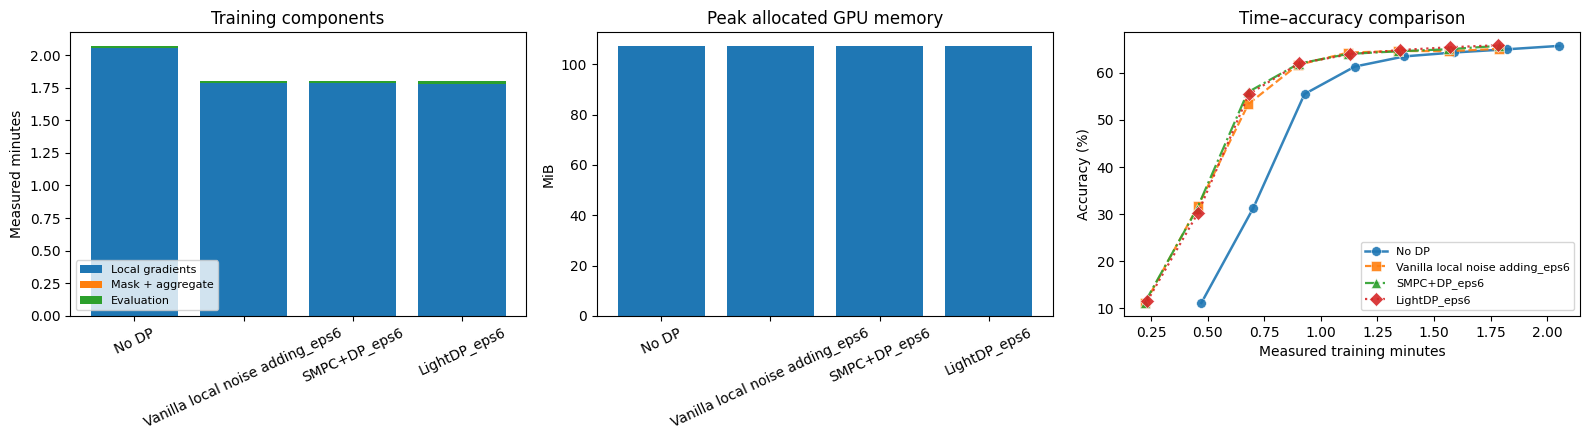

In [10]:
perf=pd.DataFrame([dict(run=r['tag'],measurement_gpu=r['measurement_gpu'],rounds=r['completed'],local_seconds=r['local_seconds'],mask_seconds=r['mask_seconds'],
                        eval_seconds=r['eval_seconds'],training_seconds=r['train_seconds'],
                        standalone_seconds=feature_original_seconds+r['train_seconds']+r['eval_seconds'],
                        peak_allocated_MiB=r['peak_allocated_MiB'],peak_reserved_MiB=r['peak_reserved_MiB'],
                        sampled_process_RSS_MiB=r['host_RSS_MiB']) for r in main])
perf['secure_protocol_seconds']=np.where(perf.run.str.startswith('SMPC+DP'),np.nan,0.)
perf.to_csv(OUT/'main_performance.csv',index=False);display(perf)
fig,axs=plt.subplots(1,3,figsize=(16,4.5))
x=np.arange(len(main));bottom=np.zeros(len(main))
for column,label in [('local_seconds','Local gradients'),('mask_seconds','Mask + aggregate'),('eval_seconds','Evaluation')]:
    values=perf[column].to_numpy()/60;axs[0].bar(x,values,bottom=bottom,label=label);bottom+=values
axs[0].set(xticks=x,xticklabels=perf.run,ylabel='Measured minutes',title='Training components');axs[0].legend(fontsize=8);axs[0].tick_params(axis='x',rotation=25)
axs[1].bar(perf.run,perf.peak_allocated_MiB);axs[1].set(ylabel='MiB',title='Peak allocated GPU memory');axs[1].tick_params(axis='x',rotation=25)
time_styles=[('o','-','tab:blue',1.8,7),('s','--','tab:orange',1.6,7),('^','-.','tab:green',1.6,7),('D',':','tab:red',1.6,7)]
for i,run in enumerate(main):
    part=hist[hist.run==run['tag']]
    mk,ls,clr,lw,ms=time_styles[i%len(time_styles)]
    axs[2].plot(part.training_seconds/60,part.accuracy,marker=mk,linestyle=ls,color=clr,linewidth=lw,markersize=ms,
                markeredgecolor='white',markeredgewidth=0.4,label=run['tag'],alpha=0.9)
axs[2].set(xlabel='Measured training minutes',ylabel='Accuracy (%)',title='Time–accuracy comparison');axs[2].legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT/'03_training_time_memory.png',dpi=180);plt.show()


## Isolated protocol costs: real mask generation and real encryption samples

The streaming LightDP implementation generates each pair once and applies opposite signs, storing only N uploads plus a temporary vector. We benchmark it against normal noise and the covariance-equivalent fast simulator. **The fast covariance sampler is a simulation shortcut, not a deployable peer protocol.** No fake sleep/network penalty is added.

A separate Paillier **2048-bit-key CPU microbenchmark** encrypts and aggregates a small 16-element vector. The full-vector encryption time is explicitly an **extrapolation**, not measured end-to-end HE-FL. Float32 and serialized ciphertext payloads are analytical byte counts; this is not a RAM comparison. CPU cryptography and GPU masking run on different hardware, so their ratio is illustrative, not a controlled algorithmic speedup. We make no claim to have implemented threshold Paillier, secure key distribution, or SecAgg.


,mechanism,median_seconds,min_seconds,max_seconds,incremental_peak_GPU_MiB
0,Normal Gaussian,0.000230,0.000227,0.000262,10.819336
1,LightDP streaming pairs,0.080781,0.077119,0.112543,10.819336
2,LightDP covariance simulator,0.000517,0.000515,0.000602,21.638672


,0
key_bits,2048.000000
sample_elements,16.000000
key_generation_seconds,0.728642
measured_encrypt_16_seconds,1.646087
measured_add_16_seconds,0.000876
measured_decrypt_16_seconds,0.471053
projected_encrypt_P_seconds,2917.894892
float32_payload_KiB,110.789062
ciphertext_fixed_width_payload_KiB,14181.000000
ciphertext_to_float_payload_ratio,128.000000


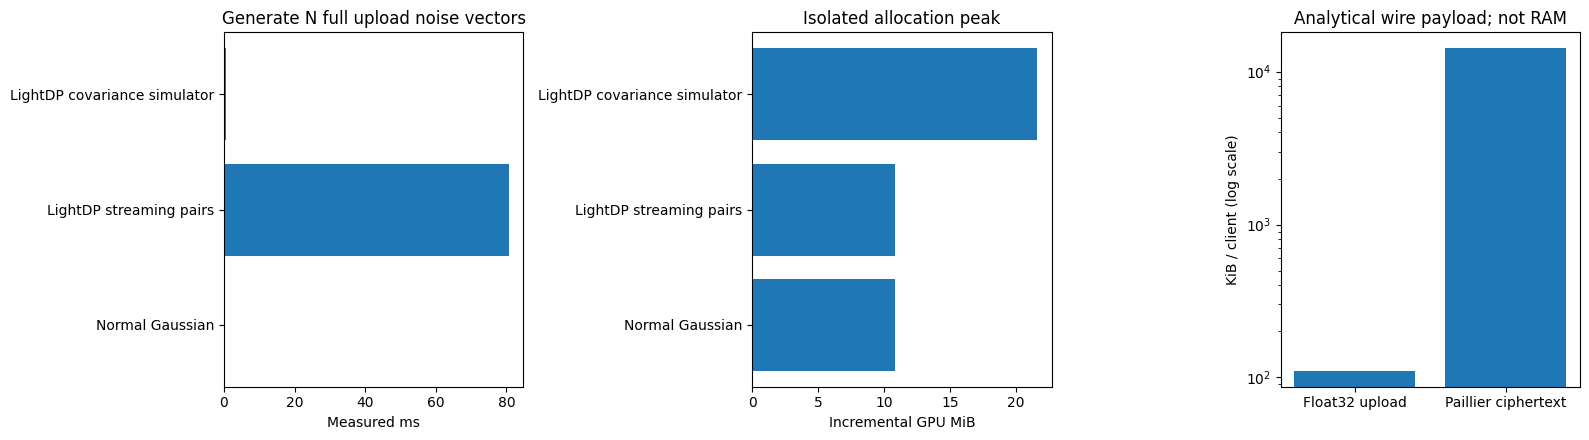

In [11]:
representative=next(r for r in main if r['method']=='LightDP')
cal=representative['cal'];N=representative['N']
DESIGN_C=representative['Cmax'];DESIGN_S=representative['Smax']
def stream_masks():
    noise=math.sqrt(cal['u'])*torch.randn(N,P,device=DEVICE)
    for i in range(N):
        for j in range(i+1,N):
            r=math.sqrt(cal['k'])*torch.randn(P,device=DEVICE)
            noise[i].add_(r);noise[j].sub_(r)
    return noise
def normal_masks():return math.sqrt(cal['normal_var'])*torch.randn(N,P,device=DEVICE)
def fast_masks():return joint_noise(N,P,cal['u'],cal['k'])
bench=[]
for name,fn in [('Normal Gaussian',normal_masks),('LightDP streaming pairs',stream_masks),('LightDP covariance simulator',fast_masks)]:
    temp=fn();del temp;sync()
    timings=[];peaks=[]
    for rep in range(5):
        gc.collect();sync();base=torch.cuda.memory_allocated();torch.cuda.reset_peak_memory_stats()
        ts=time.monotonic();temp=fn();sync();timings.append(time.monotonic()-ts)
        peaks.append((torch.cuda.max_memory_allocated()-base)/2**20);del temp
    bench.append(dict(mechanism=name,median_seconds=np.median(timings),min_seconds=min(timings),max_seconds=max(timings),incremental_peak_GPU_MiB=max(peaks)))
bench_df=pd.DataFrame(bench);display(bench_df);bench_df.to_csv(OUT/'mask_microbenchmark.csv',index=False)
from phe import paillier
ts=time.monotonic();pub,priv=paillier.generate_paillier_keypair(n_length=2048);key_seconds=time.monotonic()-ts
values=np.linspace(-.1,.1,16).tolist()
enc_times=[]
for rep in range(3):
    ts=time.monotonic();encrypted=[pub.encrypt(v) for v in values];enc_times.append(time.monotonic()-ts)
ts=time.monotonic();summed=[a+b for a,b in zip(encrypted,encrypted)];aggregation_seconds=time.monotonic()-ts
ts=time.monotonic();decoded=[priv.decrypt(v) for v in summed];decryption_seconds=time.monotonic()-ts
assert np.allclose(decoded,2*np.array(values))
cipher_bytes=math.ceil(2*pub.n.bit_length()/8)
he=dict(key_bits=2048,sample_elements=16,key_generation_seconds=key_seconds,
        measured_encrypt_16_seconds=float(np.median(enc_times)),measured_add_16_seconds=aggregation_seconds,
        measured_decrypt_16_seconds=decryption_seconds,
        projected_encrypt_P_seconds=float(np.median(enc_times))*P/16,
        float32_payload_KiB=P*4/1024,ciphertext_fixed_width_payload_KiB=P*cipher_bytes/1024,
        ciphertext_to_float_payload_ratio=cipher_bytes/4)
display(pd.Series(he));(OUT/'paillier_microbenchmark.json').write_text(json.dumps(he,indent=2))
fig,axs=plt.subplots(1,3,figsize=(16,4.5))
axs[0].barh(bench_df.mechanism,bench_df.median_seconds*1000);axs[0].set(xlabel='Measured ms',title='Generate N full upload noise vectors')
axs[1].barh(bench_df.mechanism,bench_df.incremental_peak_GPU_MiB);axs[1].set(xlabel='Incremental GPU MiB',title='Isolated allocation peak')
axs[2].bar(['Float32 upload','Paillier ciphertext'],[he['float32_payload_KiB'],he['ciphertext_fixed_width_payload_KiB']]);axs[2].set(ylabel='KiB / client (log scale)',title='Analytical wire payload; not RAM');axs[2].set_yscale('log')
fig.tight_layout();fig.savefig(OUT/'04_protocol_costs.png',dpi=180);plt.show()


## Reconstruction against the actual hybrid model

We use one fixed audit model (the final no-DP model) across all defenses, so differences are due to the observations rather than different weights. The attack differentiates through **both the public ResNet and the trained CNN branch**. Predetermined public test images are used so publishing originals does not expose protected training data.

The attacker knows the label and receives a target gradient isolated from a normal m-record client mean, granting it the other m−1 records' clipped gradients. For LightDP it also knows other honest clean updates and conditions out their noises after colluders reveal masks. The remaining target-noise variance is m²/(Σ⁻¹)ᵢᵢ. Vanilla local noise adding uses m²v₀. This is a deliberately strong auxiliary-information stress test using the actual training calibration, not a hand-picked image-noise level.

Equal gradient-matching attack budgets are used. We extract a public feature target from the classifier-gradient block and then optimize pixels against **all trainable parameter gradients**, with a weak total-variation prior. The original image is used only after the attack to score MSE/PSNR/SSIM. The original is never used for initialization or restart selection. Failure of this attack is not proof that reconstruction is impossible. If the no-DP reconstruction is weak, report that limitation rather than claiming DP caused the failure.


## Comparison Table: LightDP-FL, SMPC+DP, and Vanilla Local Noise Adding

In [36]:

from IPython.display import display
import pandas as pd


display_names = {
    'LightDP_eps6': 'The proposed LightDP-FL',
    'SMPC+DP_eps6': 'SMPC+DP (ideal)',
    'Vanilla local noise adding_eps6': 'Vanilla local noise adding',
}

rows = []
for r in main:
  if r['method'] == 'No DP':
    continue

  tag = r['tag']
  method_name = display_names.get(tag, r['method'])
  acc = last.loc[tag, 'accuracy']
  t_sec = r['train_seconds']
  t_min = t_sec / 60.0
  rounds = r['completed']
  sec_per_round = t_sec / max(1, rounds)
  eps = f"{r.get('eps', 6.0):g}"

  rows.append({
      'Method': method_name,
      'Privacy (ε)': eps,
      'Rounds': rounds,
      'Test Accuracy (%)': f'{acc:.2f}%',
      'Training Time (min)': f'{t_min:.2f} min',
      'Training Time (sec)': f'{t_sec:.1f} s',
      'Sec / Round': f'{sec_per_round:.1f} s',
  })

table_3_methods = pd.DataFrame(rows)

order = [
    'The proposed LightDP-FL',
    'SMPC+DP (ideal)',
    'Vanilla local noise adding',
]
table_3_methods['order'] = table_3_methods['Method'].map(
    lambda x: order.index(x) if x in order else 99
)
table_3_methods = (
    table_3_methods.sort_values('order')
    .drop(columns=['order'])
    .reset_index(drop=True)
)

print('\n' + '=' * 80)
print('       COMPARISON OF 3 PRIVATE METHODS: ACCURACY & RUNNING TIME')
print('=' * 80)
display(table_3_methods)

table_3_methods.to_csv(OUT / 'comparison_3_methods.csv', index=False)
(OUT / 'comparison_3_methods.md').write_text(
    table_3_methods.to_markdown(index=False), encoding='utf-8'
)
print(f"Table saved to: {OUT / 'comparison_3_methods.csv'}")


       COMPARISON OF 3 PRIVATE METHODS: ACCURACY & RUNNING TIME


,Method,Privacy (ε),Rounds,Test Accuracy (%),Training Time (min),Training Time (sec),Sec / Round
0,The proposed LightDP-FL,6,8,65.86%,1.78 min,106.8 s,13.4 s
1,SMPC+DP (ideal),6,8,65.72%,1.79 min,107.2 s,13.4 s
2,Vanilla local noise adding,6,8,65.09%,1.79 min,107.3 s,13.4 s


Table saved to: /content/lightdp_paper_comparison_results/comparison_3_methods.csv


## Save measured conclusions, all plots and checkpoints

The report distinguishes: measured accuracy, measured GPU timing/memory, measured encryption microbenchmarks, projected encryption costs, analytical privacy, and Monte Carlo dropout noise. LightDP has the **same target privacy** as vanilla local noise adding in the main comparison; lower aggregate noise can improve accuracy. “Lightweight” does not mean less model training work or less RAM than no DP.

All released private training runs compose. The combined DP-only bound below uses the same declared delta and assumes a consistent fixed client partition; **the cross-partition and label-sorted exploratory runs are excluded from this single-partition composition statement**. Their individual bounds are conditional on their fixed memberships. Publishing no-DP models invalidates a private release regardless. This public CIFAR-10 notebook is for research demonstration, not a private deployment.


In [14]:
main_acc=last.loc[[r['tag'] for r in main],'accuracy'].copy()
main_acc.index=[r['method'] for r in main]
fixed_partition_runs=[r for r in all_runs if r['cal'] is not None and r['N']==CFG['n_clients'] and not r['skew']]
combined_rho=sum(r['completed']*r['cal']['rho_round'] for r in fixed_partition_runs)
normal_perf=perf.set_index('run').loc['Vanilla local noise adding_eps6'];light_perf=perf.set_index('run').loc['LightDP_eps6']
report=[
    '# Expanded CIFAR-10 / LightDP-FL measured report','',
    f'Training images: 50,000; test images: 10,000. Main clients: {N}; records/client: {50000//N}.',
    f'Main rounds completed: {MAIN_COMPLETED}/{MAIN_ROUNDS}; sweep rounds: {sweeps[0]["completed"]}/{SWEEP_ROUNDS}.',
    f'Model: fixed public ResNet-18 at 224 pixels + trainable CNN branch/head ({P:,} parameters). Not end-to-end ResNet training.',
    f'No DP accuracy: {main_acc["No DP"]:.2f}%; Vanilla local noise adding: {main_acc["Vanilla local noise adding"]:.2f}%; LightDP: {main_acc["LightDP"]:.2f}%.',
    f'LightDP minus vanilla local noise adding: {main_acc["LightDP"]-main_acc["Vanilla local noise adding"]:+.2f} percentage points.',
    f'Normal actual epsilon: {last.loc["Vanilla local noise adding_eps6","epsilon"]:.3f}; LightDP actual epsilon: {last.loc["LightDP_eps6","epsilon"]:.3f}, delta={CFG["delta"]}.',
    f'Measured LightDP/Normal training-time ratio: {light_perf.training_seconds/normal_perf.training_seconds:.3f}. Below 1 means faster.',
    f'Measured LightDP/Normal GPU peak allocation ratio: {light_perf.peak_allocated_MiB/normal_perf.peak_allocated_MiB:.3f}. Below 1 means lower memory.',
    f'SMPC+DP accuracy (ideal secure aggregation): {main_acc["SMPC+DP"]:.2f}%. Cryptographic runtime excluded from training timing.',
    'Lightweight claim: small float uploads and no per-round dropout mask recovery. Normal independent DP may be cheaper.',
    f'Paillier sample: {he["measured_encrypt_16_seconds"]:.4f}s for 16 elements; projected full P encryption: {he["projected_encrypt_P_seconds"]:.2f}s/client. Projection is NOT measured full HE-FL.',
    'See sweep chart for epsilon 3/6/9, client count, colluders, stragglers, clip, LR and non-IID comparisons. Short sweeps are screening evidence.',
    f'Combined fixed-partition DP-only runs epsilon bound: {eps_from_rho(combined_rho,CFG["delta"]):.3f}. Excludes changed partitions and all no-DP outputs.',
    'Reconstruction results apply only to this fixed-label, strong auxiliary-information attack. Do not claim impossible reconstruction.',
    'Paper-style comparison: see 07_paper_style_epsilon_comparison.png for epsilon 3/6/9.',
    'Exact no-DP linear probe: see 00_exact_pixel_reconstruction.png. Hybrid-model reconstruction is a separate experiment.',
    'Cached results preserve original measured training times; this session wall time includes cache load/export.',
    f'Total actual runtime: {(time.monotonic()-START)/60:.2f} minutes; shared feature preparation: {feature_seconds/60:.2f} minutes.'
]
(OUT/'REPORT.md').write_text('\n'.join(report),encoding='utf-8');print('\n'.join(report))
last.to_csv(OUT/'all_final_results.csv')
meta=dict(torch=torch.__version__,torchvision=torchvision.__version__,python=platform.python_version(),gpu=torch.cuda.get_device_name(),config=CFG,plan=plan)
(OUT/'environment.json').write_text(json.dumps(meta,indent=2))
archive=OUT.parent/'lightdp_expanded_results.zip'
with zipfile.ZipFile(archive,'w',zipfile.ZIP_DEFLATED) as z:
    for file in OUT.iterdir():
        if file.is_file():z.write(file,arcname=file.name)
print('Results:',archive)
from google.colab import files
files.download(str(archive))


# Expanded CIFAR-10 / LightDP-FL measured report

Training images: 50,000; test images: 10,000. Main clients: 50; records/client: 1000.
Main rounds completed: 8/8; sweep rounds: 3/3.
Model: fixed public ResNet-18 at 224 pixels + trainable CNN branch/head (28,362 parameters). Not end-to-end ResNet training.
No DP accuracy: 65.72%; Vanilla local noise adding: 65.09%; LightDP: 65.86%.
LightDP minus vanilla local noise adding: +0.77 percentage points.
Normal actual epsilon: 6.000; LightDP actual epsilon: 6.000, delta=1e-05.
Measured LightDP/Normal training-time ratio: 0.996. Below 1 means faster.
Measured LightDP/Normal GPU peak allocation ratio: 1.000. Below 1 means lower memory.
SMPC+DP accuracy (ideal secure aggregation): 65.72%. Cryptographic runtime excluded from training timing.
Lightweight claim: small float uploads and no per-round dropout mask recovery. Normal independent DP may be cheaper.
Paillier sample: 1.6461s for 16 elements; projected full P encryption: 2917.89s/client. Pro

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### What reruns after an edit?

| Changed item | What is reused / recomputed |
|---|---|
| Plot style, title, legend, report wording | Training and feature caches are reused; figures/report regenerate |
| Attack steps, restarts, images, attack implementation | Training reused; only affected reconstruction cache keys change |
| One sweep's ε, Cmax, Smax, clip or LR | Unchanged runs reused; changed experiment trains again |
| Main rounds or model/privacy/training implementation | Affected training invalidated; noise is recalibrated from scratch |
| Feature resolution, preprocessing, public weights or dataset | Features and dependent models invalidated |
| Interrupted Colab training | Rerun all; resume each unchanged run from its five-round checkpoint |

The cached timing plan prevents time already spent in the session from changing training dependencies. Keys include source code, dataset fingerprints, initialization, privacy parameters and library versions. Cached results are **not silently reused after a consequential change**. Training caches do not include plotting functions, so you can edit plots without training again. Small diagnostics, the synthetic pilot and microbenchmarks may rerun; the expensive training and feature extraction do not.

Drive mounting is interactive on first use. Keep cache files in your own Drive; the notebook loads PyTorch objects from that trusted location. To intentionally start fresh, choose a new cache folder instead of deleting unrelated Drive files.


### Interpretation checklist for your presentation

- Show the actual plan and completed rounds first. More runtime alone is not proof of better science.
- Show no-DP/normal-DP/LightDP accuracy at matched rounds and actual epsilon. Do not substitute sweep accuracy into the main comparison.
- Explain the trained CNN branch and the frozen public ResNet accurately.
- Label measured time, peak allocated GPU memory, analytical payload and projected Paillier time separately.
- Use straggler noise and collusion privacy plots alongside the measured Cmax/Smax retraining bars.
- Show all predetermined attack images, even unsuccessful no-DP reconstructions. This is one seed, not a statistical replication.

References: [paper](https://arxiv.org/abs/2412.06120), [Gaussian zCDP/composition](https://arxiv.org/abs/1605.02065), [PyTorch per-example gradients](https://docs.pytorch.org/tutorials/intermediate/per_sample_grads.html), [torchvision ResNet-18](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).
